Batarya Ömür Tahmini Projesi (Battery Aging Prediction Project)

Veriyi İlk İnceleme (Data Exploration)

-Tüm veri içinden bir tane batarya seçip verilerini inceledim, gerekli veriler üzerinde yapılacak yumuaşatma işlemi için pencere aralıkları belirledim ve dQ/dV değerini hesapladım
(Picked one battery from all data and inspected its data, decided the window sizes for smoothing the essential data and calculated the dQ/dV value).

1. Gerekli kütüphaneleri koda ekledim (Added essential libraries to the code).

In [1]:
#Got the essential libraries
import json
import numpy as np
import matplotlib.pyplot as plt
import gc
import scipy
from scipy.signal import savgol_coeffs,savgol_filter
from numpy.lib.stride_tricks import sliding_window_view

2. Yumuşatma için veri sızıntısını engelleyen kaydırmalı pencere kullanarak savitzky-golay filtresi tanımladım
(Defined Savitzky-Golay filter for smoothing with sliding window that prevents data leakage)

In [2]:
#Defined Savitzky-Golay smoothing filter with window sliding and preventing data leakage by only looking past values
def savgol_smoothing (data, window_l, poly, method):
    #Defined coefficients
    coeffs = savgol_coeffs(window_l, poly, pos=window_l-1)
    #Picked the method based on input and smoothed the data
    if method == "correlate":
        smoothened_data = np.correlate(data, coeffs, "valid")
    elif method == "view":
        windows = sliding_window_view(data, window_l)
        smoothened_data = windows @ coeffs
    else:
        raise ValueError("Wrong method! Pick 'correlate' or 'view'")
    #Output the data
    return smoothened_data

2. Bir tane .json tipinde batarya verisi dosyası seçtikten sonra, içindeki interpolated verileri alıp, matrislerini tekrar boyutlandırdım
(Picked one .json type battery data file, then got the interpolated values inside and reshaped their matrixes).

In [3]:
#Opened the json file
with open("FastCharge/FastCharge_000015_CH14_structure.json", encoding='utf-8') as f:
    battery = json.load(f)

#Got the battery charging protocol for later
p = battery["protocol"]
print(p)
protocol = p.rpartition("\\")[2]
protocol_no_file = protocol.rpartition(".")[0]
protocol_no_date = protocol_no_file.partition("-")[2]
protocol_lower_case = protocol_no_date.lower()
print(protocol_lower_case)

#Searched the interpolated values from the file
interpolated_values = battery.get("cycles_interpolated",{})

#Refined a dictionary for reshaped value matrixes
interpolated_values_reshaped = {}

#Examined each numerical value matris in interpolated values and transformed the values to float32 format
for key,flat_list in interpolated_values.items():
    try:
        np_array = np.array(flat_list,dtype=np.float32)
    except ValueError:
        del flat_list
        continue

    #Reshaped matrises to 1000 values for each cycle to analyse easily
    cycles = len(np_array) // 1000
    if cycles > 0:
        reshaped_matrix = np_array[:cycles * 1000].reshape(cycles,1000)
        interpolated_values_reshaped[key] = reshaped_matrix
    
    #Deleted the values after reshaping and saving matrixes
    del flat_list
    del np_array
    del reshaped_matrix

#Deleted the saved battery data for clean memory usage
del f
del battery
del interpolated_values
gc.collect()

2018-04-12_batch8\20180412-5_6C_19per_4_6C_newstructure.sdu
5_6c_19per_4_6c_newstructure


0

3. Veriyi temizleyip, değişkenlerin grafiklerini çizdirdim
(Cleaned up the data and plotted the graphics of variables).

Text(0.5, 1.0, 'Varience of the Temperature in each Cycle')

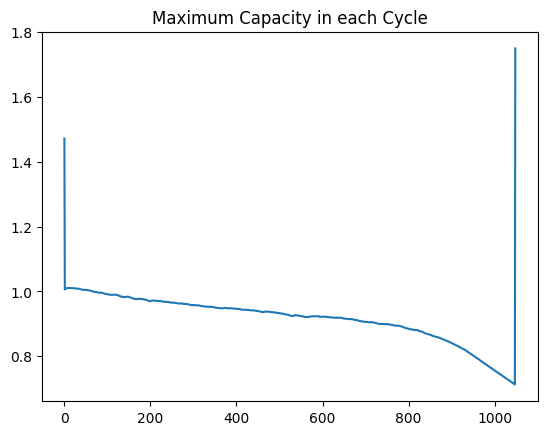

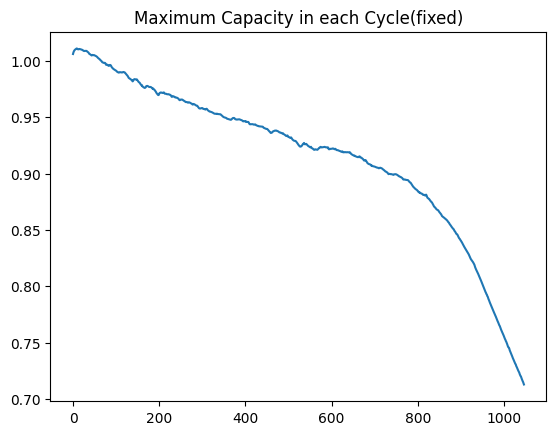

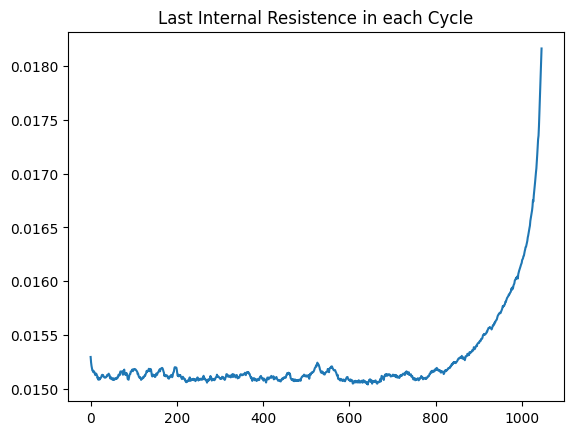

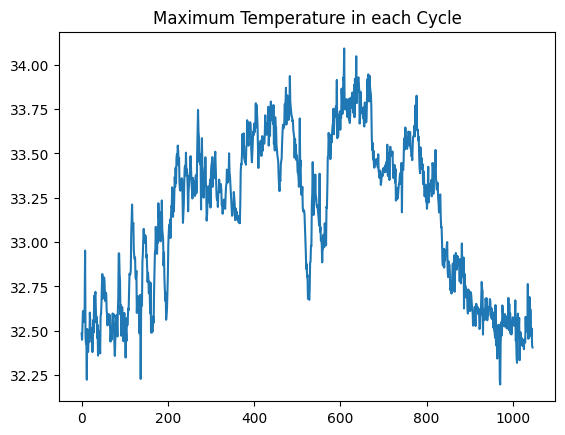

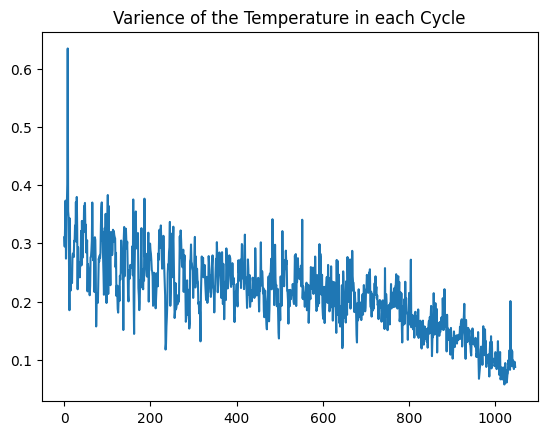

In [4]:
#Cut data in half and took the discharge values
half = cycles // 2
interpolated_values_discharge = {k:v[:half] for k,v in interpolated_values_reshaped.items()}

#Found the maximum capacity value
capacity = interpolated_values_discharge["discharge_capacity"]
max_capacity = np.zeros(half)
for i in range(half):
    max_capacity[i] = np.max(capacity[i,:])

#Plotted the maximum capacity graph
plt.figure(1)
plt.plot(max_capacity)
plt.title("Maximum Capacity in each Cycle")

#Cut the first and last cycle to clean the messy data
interpolated_values_discharge_f = {k:v[1:-1,:] for k,v in interpolated_values_discharge.items()}

#Got the interpolated values
capacity_f = interpolated_values_discharge_f["discharge_capacity"]
voltage = interpolated_values_discharge_f["voltage"]
ir = interpolated_values_discharge_f["internal_resistance"]
temperature = interpolated_values_discharge_f["temperature"]

#Got a singular value for each cycle using statistical and numerical values
max_capacity_f = np.zeros(half-2)
last_ir = np.zeros(half-2)
temp_var = np.zeros(half-2)
temp_max = np.zeros(half-2)

for i in range(half-2):
    max_capacity_f[i] = np.max(capacity_f[i,:])
    last_ir[i] = ir[i,-1]
    temp_max[i] = np.max(temperature[i,:])
    temp_var[i] = np.var(temperature[i,:])

#Plotted the value graphs
plt.figure(2)
plt.plot(max_capacity_f)
plt.title("Maximum Capacity in each Cycle(fixed)")

plt.figure(3)
plt.plot(last_ir)
plt.title("Last Internal Resistence in each Cycle")

plt.figure(4)
plt.plot(temp_max)
plt.title("Maximum Temperature in each Cycle")

plt.figure(5)
plt.plot(temp_var)
plt.title("Varience of the Temperature in each Cycle")





4. Veriye yumuşatma uygulayıp,grafikler ile kontrol ederek pencere aralığını optimize ettim
(Smoothened the data, and optimized window size with grpahics)

Text(0.5, 1.0, 'Last Internal Resistence in each Cycle (Smoothened w correlate)')

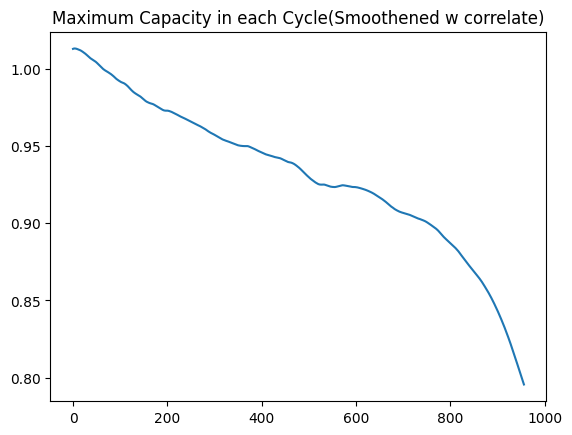

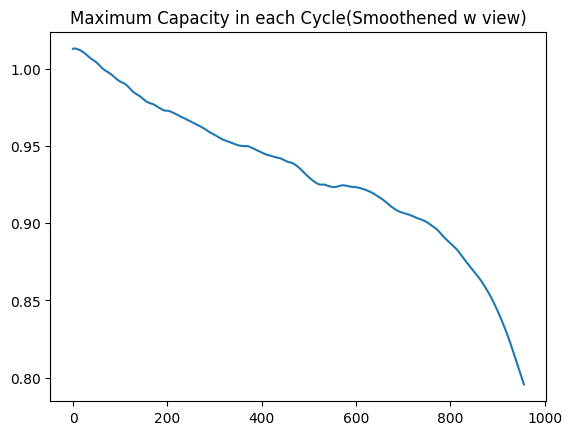

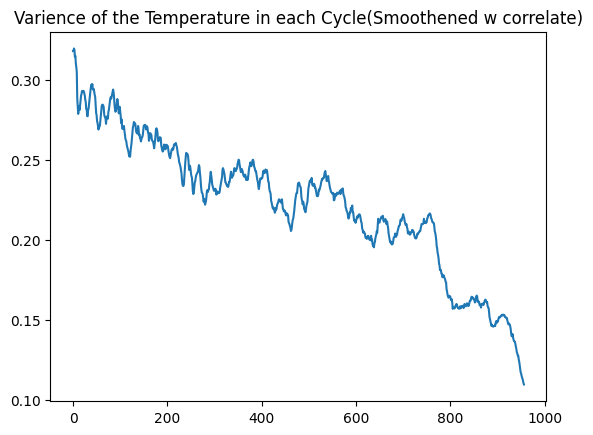

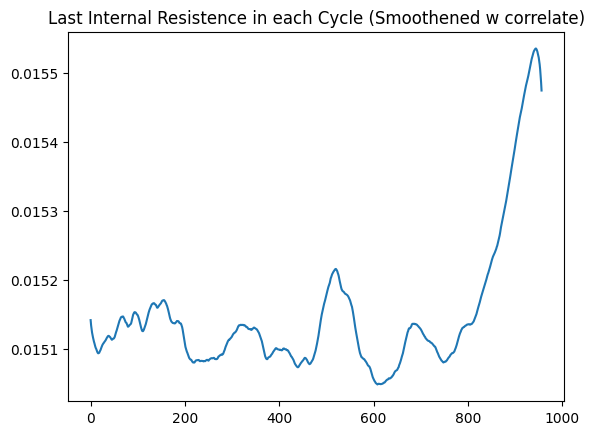

In [5]:
#Smoothened the capacity values using Savitzky-Golay function defined before
smooth_max_capacity = savgol_smoothing(max_capacity_f, window_l=91 ,poly=1, method="correlate")
smooth_max_capacity_2 = savgol_smoothing(max_capacity_f, window_l=91 ,poly=1, method="view")

#Plotted the graphs to see the difference between two methods of smoothing
plt.figure(1)
plt.plot(smooth_max_capacity)
plt.title("Maximum Capacity in each Cycle(Smoothened w correlate)")

plt.figure(2)
plt.plot(smooth_max_capacity_2)
plt.title("Maximum Capacity in each Cycle(Smoothened w view)")

#Smoothened the varience of temperature in each cycle and plotted its graph
smooth_temp_var = savgol_smoothing(temp_var, window_l=91,poly=1,method="correlate")

plt.figure(3)
plt.plot(smooth_temp_var)
plt.title("Varience of the Temperature in each Cycle(Smoothened w correlate)")

#Smoothened the last internal resistance in each cycle and plotting its graph
smooth_last_ir = savgol_smoothing(last_ir, window_l=91 ,poly=1, method="correlate")

plt.figure(4)
plt.plot(smooth_last_ir)
plt.title("Last Internal Resistence in each Cycle (Smoothened w correlate)")


5. dQ/dV hesaplayıp, istatistiksel değerlerini inceledim
(Calculated dQ/dV, inspected its statistical values)

21057

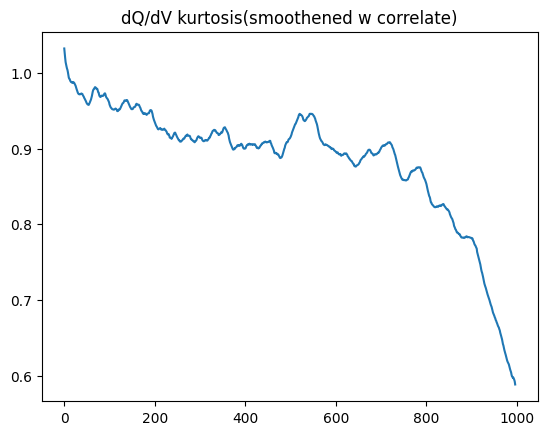

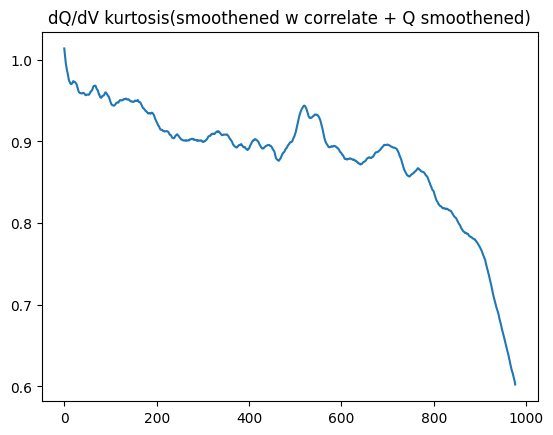

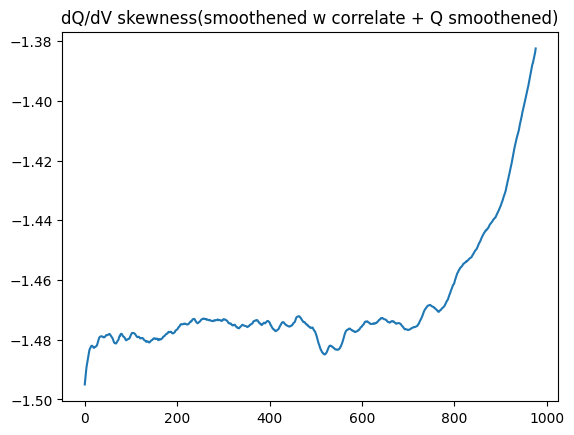

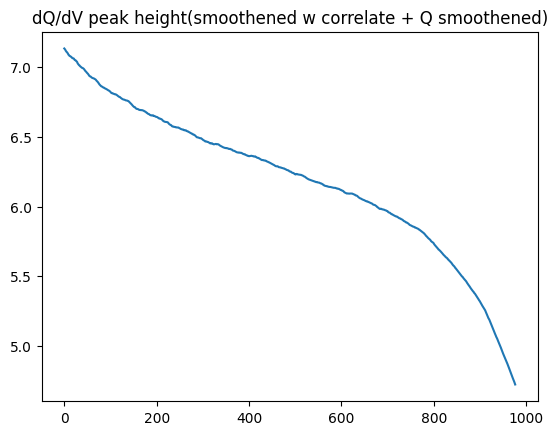

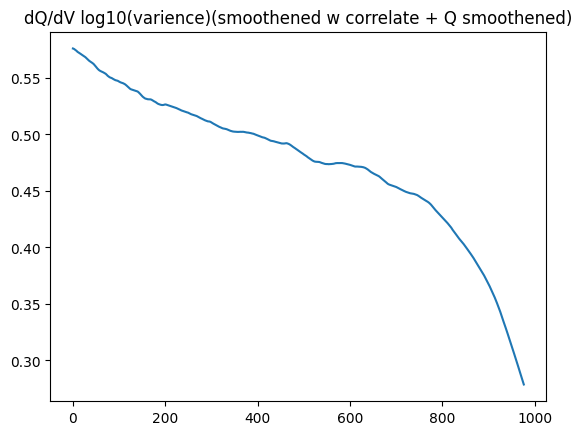

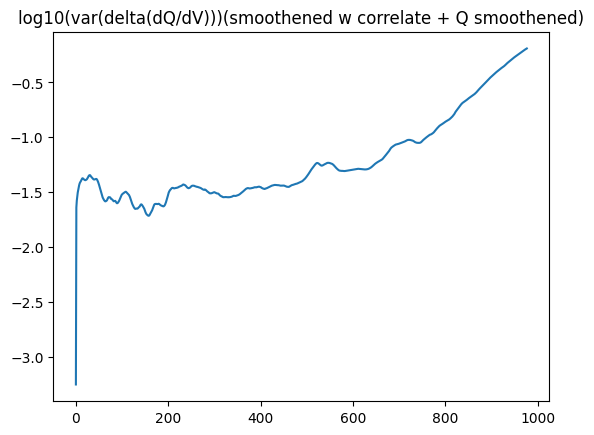

In [6]:
#Calculated the dQ/dV values
Q_V_derivative = np.gradient(capacity_f,voltage[0],axis=1)

#Calculated its kurtosis for each cycle
Q_V_derivative_kurtosis = np.zeros(half-2)

for i in range(half-2):
    Q_V_derivative_kurtosis[i] = scipy.stats.kurtosis(Q_V_derivative[i,:])

#Smoothened the kurtosis value of dQ/dV and plotted its graph
smooth_QV_derivative_kurtosis = savgol_smoothing(Q_V_derivative_kurtosis, window_l=51 ,poly=1, method="correlate")

plt.figure(1)
plt.plot(smooth_QV_derivative_kurtosis)
plt.title("dQ/dV kurtosis(smoothened w correlate)")

#Smoothened Capacity values using centered Savitzky-Golay filter
smooth_capacity_f = np.zeros((half-2,1000))
for i in range(half-2):
    smooth_capacity_f[i,:] = savgol_filter(capacity_f[i,:],window_length=21,polyorder=2)

#Defined the statistical values of smoothened dQ/dV
smooth_Q_V_derivative_kurtosis = np.zeros(half-2)
smooth_Q_V_derivative_skewness = np.zeros(half-2)
smooth_Q_V_derivative_peakheight = np.zeros(half-2)
smooth_Q_V_derivative_variance = np.zeros(half-2)
smooth_delta_Q_V_derivative = np.zeros((half-2,1000))
smooth_variance_delta_Q_V_derivative = np.zeros(half-2)
window = 10

#Calculated the dQ/dV values with smoothened capacity values
smooth_Q_V_derivative_f = np.gradient(smooth_capacity_f,voltage[0],axis=1)

#Calculated the statistical values of smoothened dQ/dV for each cycle
for i in range(half-2):
    smooth_Q_V_derivative_kurtosis[i] = scipy.stats.kurtosis(smooth_Q_V_derivative_f[i,:])
    smooth_Q_V_derivative_skewness[i] = scipy.stats.skew(smooth_Q_V_derivative_f[i,:])
    smooth_Q_V_derivative_peakheight[i] = np.max(abs(smooth_Q_V_derivative_f[i,:]))
    smooth_Q_V_derivative_variance[i] = np.log10(np.var(smooth_Q_V_derivative_f[i,:]) + (1e-3))    
    f = smooth_Q_V_derivative_f[0,:]
    if i == 0:
        smooth_delta_Q_V_derivative[i,:] = np.ones(1000)
    else:
        smooth_delta_Q_V_derivative[i,:] = smooth_Q_V_derivative_f[i,:] - f   
    smooth_variance_delta_Q_V_derivative[i] = np.log10(np.var(smooth_delta_Q_V_derivative[i,:] + (1e-3)))
    

#Smoothened the statistical values of smoothened dQ/dV
smoother_QV_derivative_kurtosis = savgol_smoothing(smooth_Q_V_derivative_kurtosis, window_l=71 ,poly=1, method="correlate")
smoother_QV_derivative_skewness = savgol_smoothing(smooth_Q_V_derivative_skewness, window_l=71 ,poly=1, method="correlate")
smoother_QV_derivative_peakheight = savgol_smoothing(smooth_Q_V_derivative_peakheight, window_l=71 ,poly=1, method="correlate")
smoother_QV_derivative_variance_log = savgol_smoothing(smooth_Q_V_derivative_variance, window_l=71 ,poly=1, method="correlate")
smoother_log_varience_delta_QV_derivative = savgol_smoothing(smooth_variance_delta_Q_V_derivative, window_l=71 ,poly=1, method="correlate")


#Plotted the statistical values of smoothened dQ/dV for each cycle
plt.figure(2)
plt.plot(smoother_QV_derivative_kurtosis)
plt.title("dQ/dV kurtosis(smoothened w correlate + Q smoothened)")

plt.figure(3)
plt.plot(smoother_QV_derivative_skewness)
plt.title("dQ/dV skewness(smoothened w correlate + Q smoothened)")

plt.figure(4)
plt.plot(smoother_QV_derivative_peakheight)
plt.title("dQ/dV peak height(smoothened w correlate + Q smoothened)")

plt.figure(5)
plt.plot(smoother_QV_derivative_variance_log)
plt.title("dQ/dV log10(varience)(smoothened w correlate + Q smoothened)")

plt.figure(6)
plt.plot(smoother_log_varience_delta_QV_derivative)
plt.title("log10(var(delta(dQ/dV)))(smoothened w correlate + Q smoothened)")



gc.collect()